süper — verdiğim kümeleme kodunu **satır satır değil, “blok blok ve mantık mantık”** açıklayayım. Her aşamada: **ne yapıyoruz? neden yapıyoruz? önemli parametreler ve sık hatalar** şeklinde gideceğim. En sonda da “sürüm uyumluluğu” notunu ekledim (Agglomerative’de `metric/affinity`).

---

# 0) Veriyi oku

```python
df = pd.read_csv("Mall_Customers.csv")
drop_cols = [c for c in ["CustomerID","ID","customer_id"] if c in df.columns]
df = df.drop(columns=drop_cols)
```

**Ne yapıyoruz?** CSV’yi yüklüyor, sadece analizde gereksiz olan kimlik kolonlarını atıyoruz.
**Neden?** Kimlik kolonları ölçekleme ve mesafe hesabında “anlamsız gürültü” yaratır.
**Hatırlatma:** Kolon adları (özellikle `"Annual Income (k$)"` ve `"Spending Score (1-100)"`) dosyanda farklıysa önce `print(df.columns)` ile doğrula.

---

# 1) Özellik (feature) seçimi

```python
two_feature_cols = ["Annual Income (k$)", "Spending Score (1-100)"]
use_two_features = set(two_feature_cols).issubset(df.columns)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in numeric_cols]

features_for_model = (two_feature_cols + [c for c in cat_cols if c.lower()=="gender"]) if use_two_features else (numeric_cols + cat_cols)
X = df[features_for_model].copy()
```

**Ne yapıyoruz?**

* **Senaryo A (önerilen ilk adım):** Sadece **Gelir** + **Harcama Puanı** ile çalış (görselleştirmesi kolay ve klasik).
* **Senaryo B:** Hepsiyle çalış (tüm sayısal + varsa `Gender`).

**Neden?**

* 2 özellik → direkt 2B anlaması ve çizmesi kolay.
* Tüm özellikler → daha “gerçekçi” segmentler ama görselleştirme için PCA gerekir.

**İpucu:** `Gender` kategoriktir; One-Hot ile sayısallaştıracağız.

---

# 2) Ön işleme (ColumnTransformer + Pipeline mantığı)

```python
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])
ct = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
], remainder="drop")

X_proc = ct.fit_transform(X)   # numpy array
```

**Ne yapıyoruz?**

* **Sayısal** sütunlarda: eksikleri **median** ile doldur → **StandardScaler** ile ölçekle.
* **Kategorik** sütunlarda: eksikleri **most\_frequent** ile doldur → **One-Hot** kodla.
* Hepsini **tek bir adımda** `ColumnTransformer` ile uygulayıp `X_proc` şeklinde **modela hazır** bir matris elde ediyoruz.

**Neden?**

* K-Means ve hiyerarşik kümeleme **mesafeye duyarlı**dır; **ölçekleme şarttır**.
* One-Hot, kategorikleri düzgün bir şekilde sayısal uzaya taşır.

**Önemli:**

* `drop="first"` ile dummy tuzağından kaçınırız (bir feature’ı atar).
* `handle_unknown="ignore"`: testte hiç görmediğimiz kategori gelirse hata atma.

---

# 3) K-Means için **K seçimi**: Dirsek (Elbow) + Silhouette

```python
inertias, sil_scores = [], []
for k in range(2, 11):        # K=2..10
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_proc)
    inertias.append(km.inertia_)               # WCSS (kümeler içi kareler toplamı)
    sil_scores.append(silhouette_score(X_proc, labels))

best_k_sil = range(2,11)[int(np.argmax(sil_scores))]
```

**Ne yapıyoruz?**

* K’yi 2’den 10’a deneriz.
* Her K için:

  * **Inertia/WCSS**: K arttıkça doğası gereği **düşer** (iç içe sıkılık artar).
  * **Silhouette**: $-1, 1$, **yüksek daha iyi** (kümeler ayrık + içi sıkı).

**Neden iki ölçüt?**

* **Elbow**: K \~ “kırılma noktasına” yakın seçilir; **öznel** olabilir.
* **Silhouette**: daha nesnel; **maksimum** olan K iyi adaydır.
* Çoğu kişi ikisini beraber değerlendirir (elbow’dan 2–3 aday seç → silhouette’a bak).

**Parametreler:**

* `n_init=10`: K-Means başlangıcını 10 kez deneyip en iyisini al; **tavsiye edilir**.
* `random_state`: tekrarlanabilirlik.

---

# 4) K-Means’i **seçilen K** ile eğit ve 2B görselleştir

```python
kmeans = KMeans(n_clusters=best_k_sil, n_init=10, random_state=42)
km_labels = kmeans.fit_predict(X_proc)

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_proc)
centers_2d = pca.transform(kmeans.cluster_centers_)
```

**Ne yapıyoruz?**

* Silhouette’a göre en iyi K ile K-Means’i **final** olarak eğitiyoruz.
* Görselleştirme için **PCA(2D)**: yüksek boyutu 2 bileşene indiriyoruz.
* Küme merkezlerini de PCA uzayına **projeksiyon** yapıp X işaretiyle çiziyoruz.

**Neden?**

* İnsan gözü 2B’yi sever :) Yüksek boyutta küme ayrımını görmek mümkün değil.
* **Uyarı:** PCA sadece görselleştirme içindir; asıl kümeleme **orijinal (ölçeklenmiş) uzayda** yapılıyor.

---

# 5) Hiyerarşik kümeleme ve dendrogram

```python
from scipy.cluster.hierarchy import linkage, dendrogram
Z = linkage(X_proc, method="ward", metric="euclidean")

# ... dendrogram(Z, ...) çiz
```

**Ne yapıyoruz?**

* **Ward linkage** + **Euclidean** ile birleşimleri hesaplıyoruz.
* **Dendrogram**, hangi gözlemlerin/ara kümelerin hangi mesafelerde birleştiğini gösterir.
* Grafikte **yükseğe çıktıkça** birleştirme **daha geç** yapılmış demektir (daha uzak, daha farklı kümeler).

**Neden?**

* Hiyerarşik yöntem, veri yapısını **ağaç** gibi gösterir; **K’yi grafikten** yorumlayabilirsin (bir **yükseklikten keserek** K belirlenir).

**Önemli:**

* `linkage="ward"` kullanıyorsan **mesafe Euclidean olmak zorundadır**.
* Çok veri varsa dendrogram aşırı kalabalık olur; `truncate_mode="level"` gibi seçeneklerle kısalt.

---

# 6) AgglomerativeClustering ile etiketle

```python
# sklearn >= 1.2
agg = AgglomerativeClustering(n_clusters=best_k_sil, linkage="ward")  # euclidean sabit
# (eski sürümde: affinity='euclidean' yazılır)
agg_labels = agg.fit_predict(X_proc)
```

**Ne yapıyoruz?**

* Dendrogramdan (veya K-Means’teki K’dan) esinle K’yi seçip **agglomerative** (aşağıdan yukarı) hiyerarşik kümeleme etiketi alıyoruz.
* Sonucu yine PCA(2D) üzerinde renklendirerek gösteriyoruz.

**Neden?**

* Hiyerarşik yöntemler K-Means’ten farklı varsayımlarda bulunur; bazen **daha doğal** segmentler verir.
* İki yöntemden gelen K/etiketleri **iş mantığı** ile kıyaslayıp karar verebilirsin.

**Sürüm uyarısı:**

* Yeni sklearn’de `metric`, eski sklearn’de `affinity` parametresi vardır. `ward` + euclidean sabit olduğundan parametre vermesen de olur (en sorunsuz yol).

---

# 7) Küme profilleme (işe çevirme)

```python
prof_df = X.copy()                 # ölçek öncesi orijinal değerlere bakmak için
prof_df["KMeansCluster"] = km_labels
prof_summary = prof_df.groupby("KMeansCluster").agg(["mean","median","count"])
```

**Ne yapıyoruz?**

* Her kümenin **gelir/harcama/yaş vb. ortalama/medyan** değerlerine bakıyoruz.
* “Küme-0: yüksek gelir, orta harcama”, “Küme-1: düşük gelir, yüksek harcama” gibi **pazarlama personası** çıkarıyoruz.

**Neden?**

* Kümeleme tek başına amaç değil; **yorumlanabilir segmentler** çıkarmak esas.
* Sonra her kümeye farklı kampanya/ürün/limit tanımlayabilirsin.

---

## Değerlendirme — “iyi kümeleme” nasıl anlaşılır?

* **Silhouette** ortalaması **yüksek** (ör. 0.4–0.6 iyi sayılır; veri setine göre değişir).
* **Kümeler arası uzaklık** (PCA 2D’de bile) **belirgin**; kümeler içi **yayılım** göreli **az**.
* **İş mantığı** ile uyumlu: Segmentler **farklı profiller** içeriyor (sadece matematiksel değil, gerçekten anlamlı).
* Farklı K’lerde sonuçları kıyasla; **elbow** + **silhouette** + **dendrogram** birleşik kararı en sağlıklısıdır.

---

## Sık hatalar / ipuçları

* **Ölçeklemeyi** unutmak → K-Means/hiyerarşi bozulur.
* `KMeans(n_init=10+)` kullanmamak → kötü başlatma yüzünden zayıf sonuç.
* Çok kategorik değişkeni one-hot’la şişirmek → boyut artar, K-Means kötüleşebilir; önce **özellik seçimi** yap.
* Dendrogram’ı “tam veriyle” çizmek → grafik taşar; `truncate_mode` ile kısalt.
* PCA’yı **sadece görselleştirme** için kullan; asıl kümeleme ölçeklenmiş orijinal uzayda.
* K’yı “tek kriterle” seçmek yerine **elbow + silhouette + dendrogram + iş bilgisi** ile karar ver.

---

## Sürüm uyumluluğu (Agglomerative)

* **sklearn ≤ 1.1**: `affinity="euclidean"`, `linkage="ward"`
* **sklearn ≥ 1.2**: `metric="euclidean"` (ya da **verme**, `ward` kullanınca euclidean sabit)
* En sorunsuz satır:

  ```python
  agg = AgglomerativeClustering(n_clusters=K, linkage="ward")
  ```

  (Bu, her iki sürümde de çalışır; `ward` = euclidean.)

---

istersen:

* Bu akışa **DBSCAN** / **HDBSCAN** de ekleyip “küresel olmayan kümeleri” yakalamayı,
* **Gap Statistic** ile K seçimine farklı bir bakış,
* ya da **Silhouette grafiğini örnek bazında** (silhouette plot) çizerek her kümenin içi/çakışmaları görmeyi gösterebilirim.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram

In [2]:
df = pd.read_csv("Mall_Customers.csv")

In [3]:
print("İlk 5 satır:")
print(df.head(), "\n")
print("Sütunlar:", list(df.columns), "\n")

İlk 5 satır:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40 

Sütunlar: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'] 



In [4]:
# Tipik gereksiz kolonları at (ID gibi)
drop_cols = [c for c in ["CustomerID", "ID", "customer_id"] if c in df.columns]
df = df.drop(columns=drop_cols)

In [5]:
# =========================================
# 1) Özellik seçimi (iki senaryo)
# =========================================
# Senaryo A: Sadece iki boyutla (görselleştirme kolay)
two_feature_cols = [c for c in ["Annual Income (k$)", "Spending Score (1-100)"] if c in df.columns]
use_two_features = len(two_feature_cols) == 2

# Senaryo B: Tüm sayısal + Gender (varsa)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in numeric_cols]

# Eğer iki özellik bulunamadıysa, tüm sayısal + cinsiyet kullan
if not use_two_features:
    print("Uyarı: 'Annual Income (k$)' ve/veya 'Spending Score (1-100)' bulunamadı; tüm sayısal + kategorik (varsa) kullanılacak.")
    features_for_model = numeric_cols + cat_cols
else:
    # İki özellikli basit senaryo için sadece bu ikisini kullan
    features_for_model = two_feature_cols + [c for c in cat_cols if c.lower() == "gender"]

In [6]:
X = df[features_for_model].copy()

In [7]:
print("Kullanılan özellikler:", list(X.columns))

Kullanılan özellikler: ['Annual Income (k$)', 'Spending Score (1-100)', 'Gender']


In [8]:
# =========================================
# 2) Ön işleme Pipeline (impute + encode + scale)
# =========================================
num_features = [c for c in X.columns if c in numeric_cols]
cat_features = [c for c in X.columns if c in cat_cols]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

ct = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ],
    remainder="drop"
)

X_proc = ct.fit_transform(X)  # NumPy array
print("Ön işlem sonrası şekil:", X_proc.shape)

Ön işlem sonrası şekil: (200, 3)


Silhouette'a göre en iyi K: 6 (score=0.439)


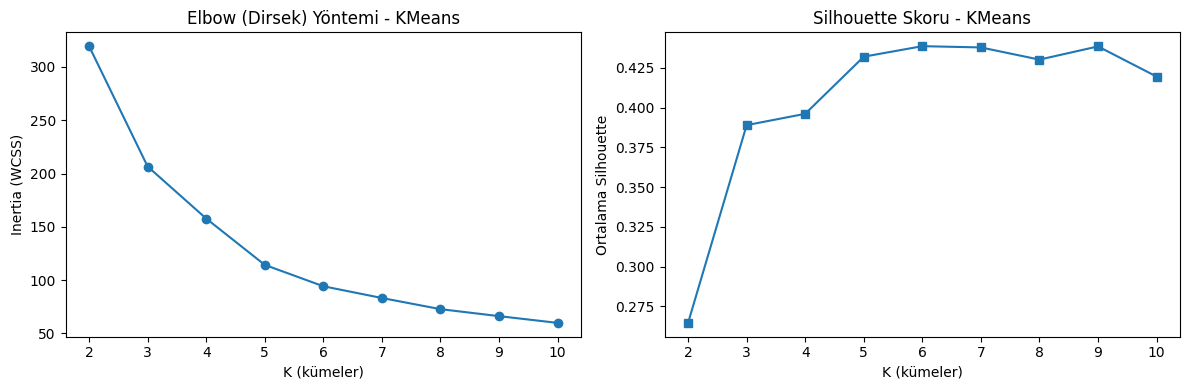

In [9]:
# =========================================
# 3) K-Means: Elbow (inertia) ve Silhouette ile K seçimi
# =========================================
inertias = []
sil_scores = []

K_range = range(2, 11)  # 2..10 arası dene (1 için silhouette tanımsız)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_proc)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_proc, labels)
    sil_scores.append(sil)

best_k_sil = K_range[int(np.argmax(sil_scores))]
print(f"Silhouette'a göre en iyi K: {best_k_sil} (score={max(sil_scores):.3f})")

# Dirsek grafikleri
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(list(K_range), inertias, marker="o")
plt.xlabel("K (kümeler)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow (Dirsek) Yöntemi - KMeans")

plt.subplot(1,2,2)
plt.plot(list(K_range), sil_scores, marker="s")
plt.xlabel("K (kümeler)")
plt.ylabel("Ortalama Silhouette")
plt.title("Silhouette Skoru - KMeans")
plt.tight_layout()
plt.show()

In [10]:
# En iyi K ile KMeans'i eğit
kmeans = KMeans(n_clusters=best_k_sil, n_init=10, random_state=42)
km_labels = kmeans.fit_predict(X_proc)

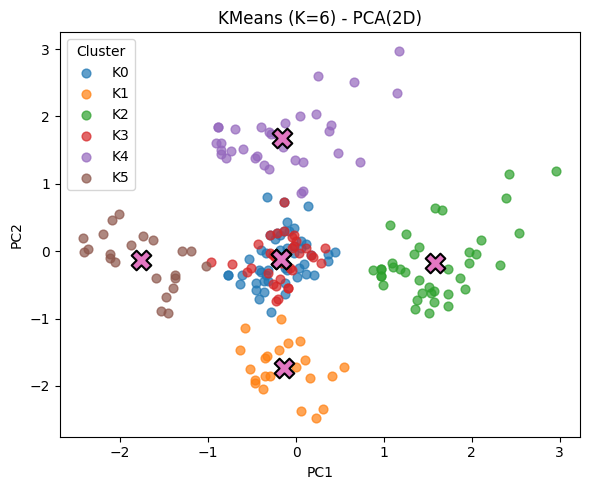

In [11]:
# =========================================
# 4) PCA ile 2B görselleştirme (merkezleri de projekte et)
# =========================================
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_proc)
centers_2d = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(6,5))
for lab in np.unique(km_labels):
    plt.scatter(X_2d[km_labels==lab,0], X_2d[km_labels==lab,1], s=40, alpha=0.7, label=f"K{lab}")
plt.scatter(centers_2d[:,0], centers_2d[:,1], s=200, marker="X", edgecolor="k", linewidths=1.5)
plt.title(f"KMeans (K={best_k_sil}) - PCA(2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

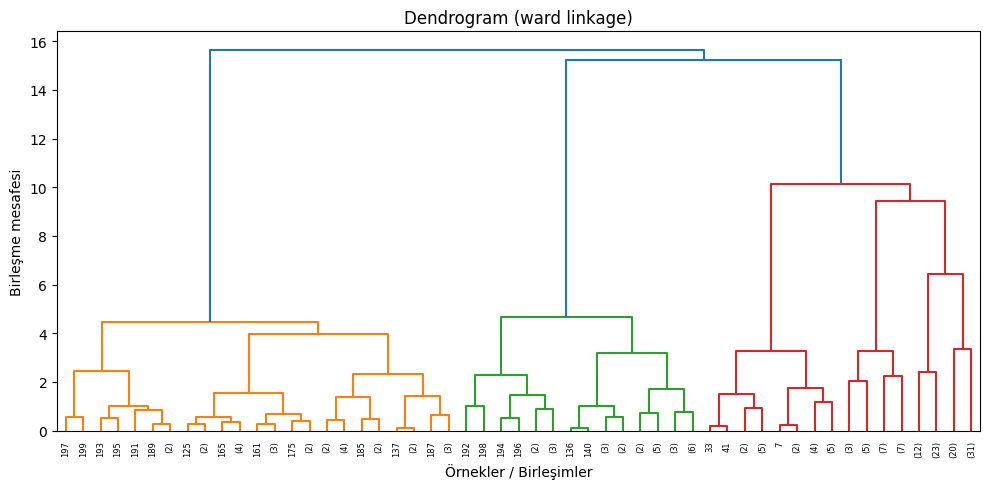

In [12]:
# =========================================
# 5) Hiyerarşik kümeleme + Dendrogram
# =========================================
# Dendrogram için scipy linkage (Ward + Euclidean)
Z = linkage(X_proc, method="ward", metric="euclidean")

plt.figure(figsize=(10,5))
dendrogram(Z, truncate_mode="level", p=5)  # çok uzun ise kısalt
plt.title("Dendrogram (ward linkage)")
plt.xlabel("Örnekler / Birleşimler")
plt.ylabel("Birleşme mesafesi")
plt.tight_layout()
plt.show()

In [17]:
# Tercihen KMeans'le bulunan K sayısını baz alarak AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=best_k_sil, linkage="ward")
agg_labels = agg.fit_predict(X_proc)

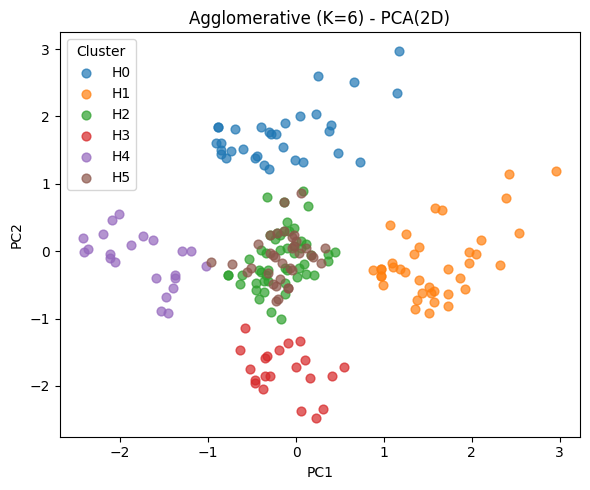

In [18]:
# Hiyerarşik etiketlerle PCA 2D
plt.figure(figsize=(6,5))
for lab in np.unique(agg_labels):
    plt.scatter(X_2d[agg_labels==lab,0], X_2d[agg_labels==lab,1], s=40, alpha=0.7, label=f"H{lab}")
plt.title(f"Agglomerative (K={best_k_sil}) - PCA(2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [19]:
# =========================================
# 6) Küme profilleme (ortalama özellik değerleri)
# =========================================
# Orijinal (ölçek öncesi) özellikler üzerinden cluster ortalamaları:
prof_df = X.copy()
prof_df["KMeansCluster"] = km_labels
prof_summary = prof_df.groupby("KMeansCluster").agg(["mean","median","count"])
print("\nKüme profilleri (KMeans):")
print(prof_summary)


Küme profilleri (KMeans):
              Annual Income (k$)              Spending Score (1-100)         \
                            mean median count                   mean median   
KMeansCluster                                                                 
0                      55.653061   57.0    49              48.591837   49.0   
1                      25.727273   24.5    22              79.363636   77.0   
2                      86.538462   79.0    39              82.128205   83.0   
3                      54.735294   54.0    34              49.852941   50.0   
4                      88.735294   85.5    34              16.764706   15.5   
5                      25.727273   24.5    22              20.227273   16.0   

                     
              count  
KMeansCluster        
0                49  
1                22  
2                39  
3                34  
4                34  
5                22  
